# 10 Live Demo for current 2025-26 NBA Playoffs


In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src import bracket, series, plot_style
plot_style.apply()

DATA = Path("..") / "data" / "processed"
df = pd.read_parquet(DATA / "games_with_advanced_features.parquet")

SEASON = 2025
season_games = df[df.season == SEASON]
playoffs = season_games[season_games.gameType == "Playoffs"]
print(f"Season {SEASON}: {len(season_games):,} games, of which {len(playoffs)} playoff games")
print(f"Last game in the dataset: {season_games.gameDate.max().date()}")

Season 2025: 1,260 games, of which 30 playoff games
Last game in the dataset: 2026-04-26


## Current ELO ranking 

Pre-playoff ELO for each team (Top 20)

In [9]:
names = pd.concat([
    df[['gameDate', 'hometeamId', 'hometeamName']].rename(columns={'hometeamId': 't', 'hometeamName': 'n'}),
    df[['gameDate', 'awayteamId', 'awayteamName']].rename(columns={'awayteamId': 't', 'awayteamName': 'n'}),
]).sort_values('gameDate').drop_duplicates('t', keep='last').set_index('t')['n']



home_v = playoffs[['gameDate', 'hometeamId', 'home_elo_pre']].rename(columns={'hometeamId': 't', 'home_elo_pre': 'e'})
away_v = playoffs[['gameDate', 'awayteamId', 'away_elo_pre']].rename(columns={'awayteamId': 't', 'away_elo_pre': 'e'})
preplay = pd.concat([home_v, away_v]).sort_values(['t', 'gameDate']).groupby('t').first()['e']

elo_table = preplay.rename(index=names).sort_values(ascending=False).head(20)
elo_table.round(0).to_frame('Pre-Playoff ELO')

,Pre-Playoff ELO
t,
Thunder,1758.0
Spurs,1707.0
Celtics,1685.0
Pistons,1662.0
Nuggets,1659.0
Cavaliers,1631.0
Knicks,1630.0
Lakers,1625.0
Rockets,1598.0


## Current R1 matchups + live results

In [10]:
playoffs = playoffs.copy()
playoffs["team_pair"] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

round1 = []

for pair, grp in playoffs.groupby("team_pair"):
    higher = grp.hometeamId.value_counts().idxmax()
    lower = [t for t in pair if t != higher][0]
    wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
             ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
    
    wins_l = len(grp) - wins_h
    
    round1.append({
        "higher": names.get(higher, str(higher)),
        "lower":  names.get(lower, str(lower)),
        "higher_elo": round(preplay.get(higher, 1500)),
        "lower_elo":  round(preplay.get(lower, 1500)),
        "series_score": f"{max(wins_h, wins_l)}-{min(wins_h, wins_l)}",
        "leader": names.get(higher, "?") if wins_h > wins_l else (names.get(lower, "?") if wins_l > wins_h else "tied"),
        "games_played": len(grp),})

    
pd.DataFrame(round1).sort_values("higher_elo", ascending=False)

,higher,lower,higher_elo,lower_elo,series_score,leader,games_played
6,Thunder,Suns,1758,1521,3-0,Thunder,3
7,Spurs,Trail Blazers,1707,1521,3-1,Spurs,4
1,Celtics,76ers,1685,1513,3-1,Celtics,4
5,Pistons,Magic,1662,1540,2-1,Magic,3
3,Nuggets,Timberwolves,1659,1587,3-1,Timberwolves,4
2,Cavaliers,Raptors,1631,1516,2-2,tied,4
0,Knicks,Hawks,1630,1563,2-2,tied,4
4,Lakers,Rockets,1625,1598,3-1,Lakers,4


## Championship probabilities ELO-based

Once the bracket is fixed i use the actual matchups

In [11]:
top16 = preplay.sort_values(ascending=False).head(16)
elos = top16.to_dict()
team_ids = list(top16.index)

seed_matchups = [(0, 7), (3, 4), (1, 6), (2, 5), (8, 15), (11, 12), (9, 14), (10, 13)]

rng = np.random.default_rng(42)
champ_counts = {t: 0 for t in team_ids}
N_SIM = 10000

for _ in range(N_SIM):
    
    r1_winners = []
    
    for hi, lo in seed_matchups:
        ta, tb = team_ids[hi], team_ids[lo]
        r1_winners.append(ta if series.simulate_b07_elo(elos[ta], elos[tb], rng=rng) else tb)
    
    r2_winners = []
    
    for i in range(0, 8, 2):
        ta, tb = r1_winners[i], r1_winners[i+1]
        higher, lower = (ta, tb) if elos[ta] >= elos[tb] else (tb, ta)
        r2_winners.append(higher if series.simulate_b07_elo(elos[higher], elos[lower], rng=rng) else lower)
    
    r3_winners = []
    
    for i in range(0, 4, 2):
        ta, tb = r2_winners[i], r2_winners[i+1]
        higher, lower = (ta, tb) if elos[ta] >= elos[tb] else (tb, ta)
        r3_winners.append(higher if series.simulate_b07_elo(elos[higher], elos[lower], rng=rng) else lower)
    
    
    ta, tb = r3_winners
    higher, lower = (ta, tb) if elos[ta] >= elos[tb] else (tb, ta)
    
    champ = higher if series.simulate_b07_elo(elos[higher], elos[lower], rng=rng) else lower
    champ_counts[champ] += 1

probs = pd.Series({names.get(t, str(t)): c / N_SIM for t, c in champ_counts.items()}).sort_values(ascending=False)

print("Top-5 championship picks for 2025-26:")
print(probs.head(5).apply(lambda v: f"{v:.1%}"))

Top-5 championship picks for 2025-26:
Thunder    47.6%
Spurs      18.2%
Celtics     9.8%
Rockets     5.9%
Pistons     4.2%
dtype: str


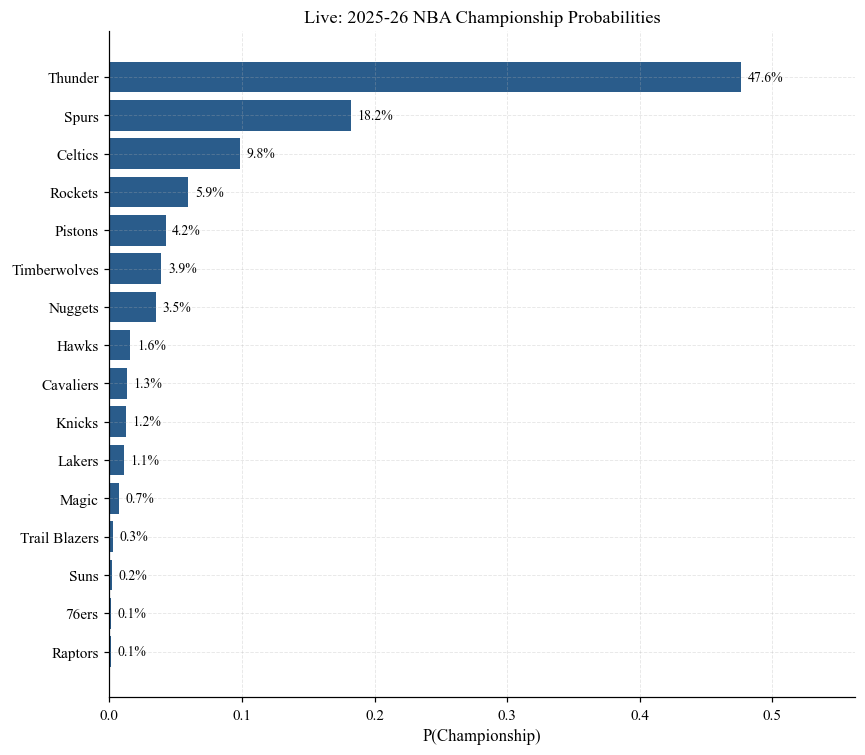

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
view = probs.sort_values()

ax.barh(view.index, view.values, color=plot_style.COLORS["primary"])
ax.set_xlabel("P(Championship)")
ax.set_title(f"Live: 2025-26 NBA Championship Probabilities")

for i, v in enumerate(view.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlim(0, max(view.values) * 1.18)
plt.tight_layout()
plt.show()